## Comparison of planting with Gilmore data

#### Gilmore site information

lat = 41.05734,  lon = -78.69149

Area = 0.25 ha

Planted: 2021

Visit 1: November 7th 2023

visit 2: October 16th 2024




In [28]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

### Load FATES

In [29]:
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20/run/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20.sofar.nc'

#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-25/run/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-25.sofar.nc'

#fates =  '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp1_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_ssp1_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'

fates = xr.open_dataset(fates,  decode_times=False)

In [30]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]
cohort_height_bins =fates.variables['fates_levheight'][:]

80


In [31]:
#print(cohort_size_bins)
print(cohort_height_bins)

<xarray.IndexVariable 'fates_levheight' (fates_levheight: 6)>
array([ 0. ,  0.1,  0.3,  1. ,  3. , 10. ], dtype=float32)
Attributes:
    long_name:  FATES height (m)


### Load data

In [32]:
gilmore_area = 0.25

In [33]:
df_orig = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/gilmore_data/Gilmore_data.csv')

In [34]:
df_orig = df_orig[df_orig.columns.drop(list(df_orig.filter(regex='Unnamed')))]

In [35]:
df_orig.head(3)

,Name,Status,Root Collar Diameter (CM) Time of Planting,SPAD Time of Planting,Height (CM) Time of Planting,Height (cm) July 15 2022,Measurements 08/02,Height (cm) October 15,RCD (mm) November 8th,"Alive/Dead Nov. 7, 2023","RCD (mm) Nov. 7, 2023","DBH (mm) Nov. 7, 2023","Height (cm) Nov. 7, 2023",RCD Growth (2022 - 2023)
0,Gilmore PA.N.M.C.N.1,Alive,0.38,NaN,10.16,NaN,15.24,15.24,4.9,0.0,NaN,NaN,NaN,NaN
1,Gilmore PA.N.M.R.N.2,Alive,0.43,NaN,15.88,NaN,30.48,66.04,0.8,1.0,12.0,11.0,280.0,11.2
2,Gilmore PA.N.M.CR.N.3,Alive,0.38,NaN,15.24,NaN,45.72,91.44,5.7,1.0,9.0,7.0,179.0,3.3


#### How many trees at the time of planting? 

In [36]:
data_nplant_t0 = df_orig['Height (CM) Time of Planting'].count() / gilmore_area

#### How many FATES plants in the first time step?

In [37]:
fates_nplant_t0 = fates.FATES_NPLANT_SZ.isel(time=1).sum(dim='fates_levscls') * 10000

In [38]:
print('No. plants at planting - Data: ', data_nplant_t0)
print('No. plants at planting - FATES: ', fates_nplant_t0.values)

No. plants at planting - Data:  904.0
No. plants at planting - FATES:  [898.13666]


#### Mean height at planting (cm)

In [39]:
hmean_planting = df_orig['Height (CM) Time of Planting'].mean()
print(hmean_planting)

22.144380530973432


### 2023 - 2024 Data

In [40]:
df = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/gilmore_data/MRV_Gilmore_2024.csv')

In [41]:
df.tail(3)

,tree,RCD10cm_24,D130cm_24,Hm_24,RCD10cm_23,D130cm_23,Hm_23,RCD_24-23,DBH 24-23,H 24-23
223,224,1.5,1.3,3.20,1.00,0.7,2.10,0.50,0.6,1.1
224,225,1.3,1.3,3.15,1.10,0.9,2.35,0.20,0.4,0.8
225,226,0.9,0.6,2.10,0.75,0.3,1.40,0.15,0.3,0.7


### Size distribution 

In [42]:
sizedist_data = pd.cut(df['D130cm_24'], cohort_size_bins.values).value_counts().sort_index()

# convert to per m2
sizedist_data_perha = sizedist_data.values / gilmore_area / 10000
print(sizedist_data_perha)

[0.0136 0.0372 0.0288 0.004  0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.    ]


In [43]:
# raw numbers (per 0.25 ha)
print(sizedist_data)

(0.0, 1.0]       34
(1.0, 2.0]       93
(2.0, 3.0]       72
(3.0, 4.0]       10
(4.0, 5.0]        0
(5.0, 10.0]       0
(10.0, 15.0]      0
(15.0, 20.0]      0
(20.0, 30.0]      0
(30.0, 40.0]      0
(40.0, 50.0]      0
(50.0, 60.0]      0
(60.0, 70.0]      0
(70.0, 80.0]      0
(80.0, 90.0]      0
(90.0, 100.0]     0
Name: D130cm_24, dtype: int64


In [44]:
nplant_3yrs = fates.FATES_NPLANT_SZ.isel(time=36) 

In [45]:
print((nplant_3yrs.values[0:4]))

[[8.5549451e-02]
 [6.0576054e-05]
 [0.0000000e+00]
 [0.0000000e+00]]


### Plot them - bargraph? 

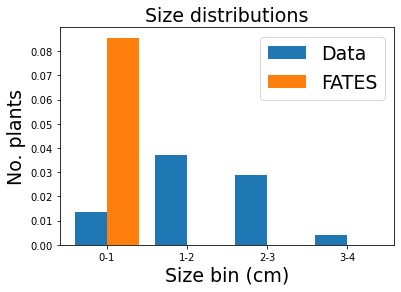

In [46]:
cats = ['0-1', '1-2', '2-3', '3-4'] # categories
vals1, vals2 = sizedist_data_perha[0:4], np.squeeze(nplant_3yrs.values)[0:4]

# Bar width and x locations
w, x = 0.4, np.arange(len(cats))

fig, ax = plt.subplots()
ax.bar(x - w/2, vals1, width=w, label='Data')
ax.bar(x + w/2, vals2, width=w, label='FATES')

ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel('No. plants', fontsize=19)
ax.set_xlabel('Size bin (cm)', fontsize=19)
ax.set_title('Size distributions', fontsize=19)
ax.legend(fontsize=19)

plt.show()

### Total number of plants - year 3

In [47]:
data_nplant_t3 = np.sum(sizedist_data.values)/gilmore_area

In [48]:
fates_nplant_t3 = fates.FATES_NPLANT_SZ.isel(time=36).sum(dim='fates_levscls') * 10000

In [49]:
print('No. plants data: ', data_nplant_t3)
print('No. plants FATES: ', fates_nplant_t3.values)

No. plants data:  836.0
No. plants FATES:  [856.1002]


### Mortality rates

In [50]:
mort_data = (np.log(data_nplant_t0)  - np.log(data_nplant_t3)) / (3 - 1)

In [51]:
mort_fates = (np.log(fates_nplant_t0)  - np.log(fates_nplant_t3)) / (3 - 1)

In [52]:
print('data mortality rate: ',  mort_data)
print('fates mortality rate: ', mort_fates.values)

data mortality rate:  0.0391003736537372
fates mortality rate:  [0.02396727]


In [53]:
m  = fates.FATES_MORTALITY_CANOPY_SZPF.sum(dim='fates_levscpf') / fates.FATES_NPLANT_CANOPY_SZPF.sum(dim='fates_levscpf')
m = m.isel(time=slice(36,48)).mean(dim='time')
print(m)


<xarray.DataArray (lndgrid: 1)>
array([0.01700003], dtype=float32)
Dimensions without coordinates: lndgrid


###  Growth rates

In [54]:
gr  = fates.FATES_DDBH_CANOPY_SZPF.sum(dim='fates_levscpf') / fates.FATES_NPLANT_CANOPY_SZPF.sum(dim='fates_levscpf')
gr = gr.isel(time=slice(36,48)).mean(dim='time') * 100

print('data growth rate: ', df['DBH 24-23'].mean() )
print('fates growth rate: ', gr)



data growth rate:  0.7883886255924168
fates growth rate:  <xarray.DataArray (lndgrid: 1)>
array([0.18676521], dtype=float32)
Dimensions without coordinates: lndgrid


Text(0, 0.5, 'Frequency')

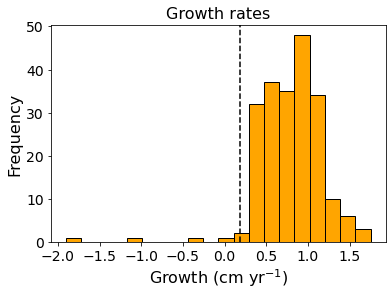

In [55]:
ax = df['DBH 24-23'].hist(grid=False, xlabelsize=14, ylabelsize=14,
                         bins=20,edgecolor='black',
                         color='orange')
ax.axvline(x=gr, color='black', linestyle='--')
# Add a bold title ('\n' allow us to jump rows)
ax.set_title('Growth rates', fontsize=16) 

# Add label names
ax.set_xlabel(r'Growth (cm yr$^{-1}$)', fontsize=16)
ax.set_ylabel('Frequency', fontsize=16)

(0.0, 24.0)

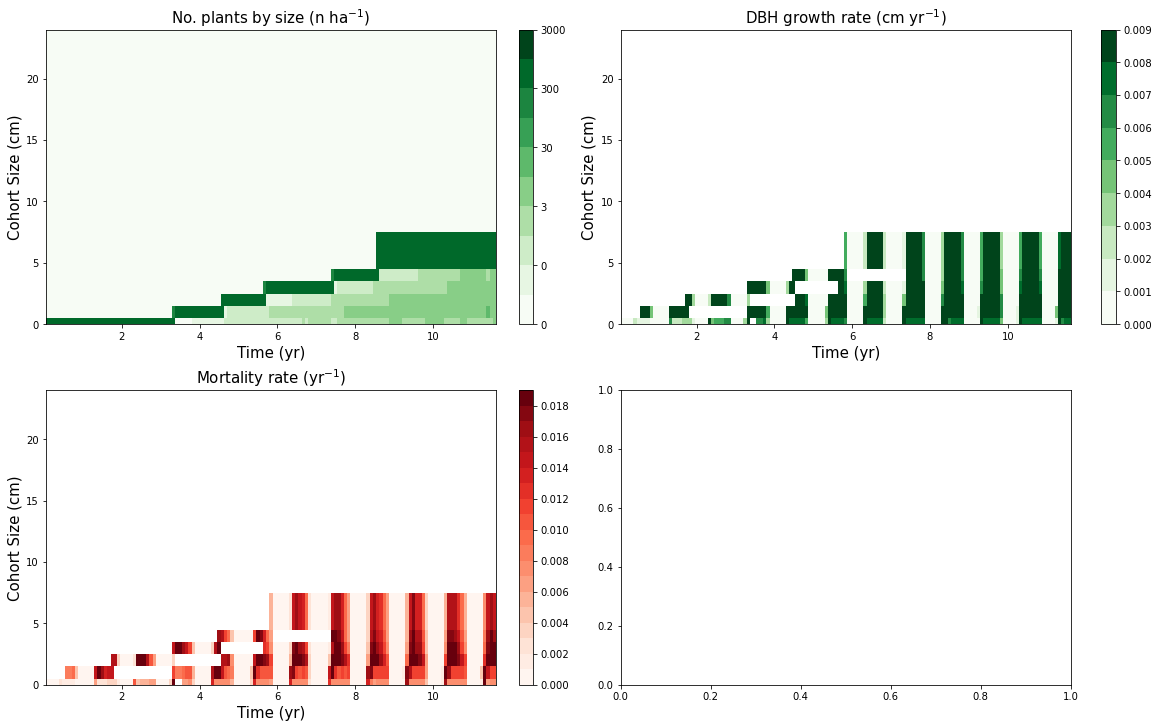

In [29]:
# population numbers as a function of cohort size
NPLANT_SZ = np.squeeze(fates.FATES_NPLANT_SZ) * 10000

DDBH = fa.scpf_to_scls_by_pft(fates.FATES_DDBH_CANOPY_SZPF, fates)
DDBH = DDBH.sum(dim='fates_levpft')
NPLANT = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_CANOPY_SZPF, fates)
NPLANT = NPLANT.sum(dim='fates_levpft')
DDBH =  np.squeeze(DDBH/NPLANT)

mort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_CANOPY_SZPF, fates)
mort = mort.sum(dim='fates_levpft')
mort =  np.squeeze(mort/NPLANT)



fig2, ((f2ax0, f2ax1),(f2ax2,f2ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10),constrained_layout=True)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f2ax0.pcolormesh(time, cohort_size_bins, (NPLANT_SZ).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'No. plants by size (n ha$^{-1}$)', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)
f2ax0.set_ylim(0,24)

levels = np.arange(0,0.01,0.001)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f2ax1.pcolormesh(time, cohort_size_bins, (DDBH).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'DBH growth rate (cm yr$^{-1}$)', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)
f2ax1.set_ylim(0,24)

levels = np.arange(0,0.02,0.001)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f2ax2.pcolormesh(time, cohort_size_bins, (DDBH).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax2)
f2ax2.set_title(r'Mortality rate (yr$^{-1}$)', fontsize=15)
f2ax2.set_xlabel('Time (yr)', fontsize=15)
f2ax2.set_ylabel('Cohort Size (cm)', fontsize=15)
f2ax2.set_ylim(0,24)
